# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


No módulo 17 vocês realizaram a primeira etapa do projeto de crédito de vocês.
Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste.
Nessa aula aplicaremos o algoritmo de naive bayes a base de vocês afim de tentarmos trazer previsões do score de crédito.

**IMPORTANTE:** Não se esqueçam de ao enviar o código de vocês para os tutores, enviarem as bases, pois como cada um de vocês realizou as alterações de tratamento indidualmente o tutor precisa ter acesso aos seus dados individuais.

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
import plotly.figure_factory as ff

Durante a aula nossa variável a ser prevista (churn) continha apenas 2 categorias, a base de vocês contém mais. O Naive Bayes pode ser aplicado para problemas de classificação com múltiplas classes da mesma forma que para problemas de classificação binária. O Naive Bayes é um algoritmo de classificação probabilístico que calcula a probabilidade de uma amostra pertencer a cada classe e seleciona a classe com a maior probabilidade como a previsão final.
Em resumo, o Naive Bayes pode ser aplicado da mesma maneira para problemas de classificação com múltiplas classes, e os mesmos princípios se aplicam em termos de treinamento, avaliação e aplicação do modelo.

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [19]:
#seu código aqui
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

In [20]:
X_test

,Age,Income,Gender_encoded,Marital_Status_encoded,Number of Children_1,Number of Children_2,Number of Children_3,Home_Ownership_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,25,55000.0,0,1,0,0,0,1,1,0,0,0
1,48,87500.0,0,0,1,0,0,0,0,1,0,0
2,26,55000.0,0,0,1,0,0,0,1,0,0,0
3,39,62500.0,0,0,0,1,0,0,1,0,0,0
4,35,90000.0,0,0,1,0,0,0,0,1,0,0
5,25,55000.0,0,1,0,0,0,1,1,0,0,0
6,48,82500.0,0,0,1,0,0,0,0,1,0,0
7,48,82500.0,0,0,1,0,0,0,0,1,0,0
8,36,95000.0,0,0,0,1,0,0,0,0,0,1
9,36,95000.0,0,0,1,0,0,0,0,0,1,0


In [21]:
y_test

,Credit_Score_encoded
0,1
1,2
2,1
3,2
4,2
5,1
6,2
7,2
8,2
9,2


In [22]:
X_train

,Age,Income,Gender_encoded,Marital_Status_encoded,Number of Children_1,Number of Children_2,Number of Children_3,Home_Ownership_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,26,45000.000000,0,1,0,0,0,1,0,0,0,0
1,29,27500.000000,0,1,0,0,0,1,0,0,1,0
2,25,62500.000000,0,1,0,0,0,1,1,0,0,0
3,29,68000.000000,0,0,0,1,0,0,0,1,0,0
4,31,65000.000000,1,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
247,29,43703.466973,0,1,0,0,0,1,0,0,0,0
248,34,47500.000000,1,1,0,0,0,1,0,0,0,0
249,29,57500.000000,0,1,0,0,0,1,0,0,0,0
250,25,60063.547817,0,1,0,0,0,1,1,0,0,0


In [23]:
y_train

,Credit_Score_encoded
0,1
1,0
2,1
3,1
4,1
...,...
247,1
248,1
249,1
250,1


In [24]:
# Contar o número de exemplos de cada classe em y_train
train_balance = y_train.value_counts()
print("Balanceamento em y_train:")
print(train_balance)

# Contar o número de exemplos de cada classe em y_test
test_balance = y_test.value_counts()
print("\nBalanceamento em y_test:")
print(test_balance)

Balanceamento em y_train:
Credit_Score_encoded
0                       84
1                       84
2                       84
Name: count, dtype: int64

Balanceamento em y_test:
Credit_Score_encoded
2                       29
0                        6
1                        6
Name: count, dtype: int64


# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [25]:
#seu código aqui
naive_Credit_Score_encoded = GaussianNB() 

naive_Credit_Score_encoded.fit(X_train, y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



,priors,None
,var_smoothing,1e-09


# 3) Faça a avaliação do modelo com os dados de treinamento.
Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
recall = recall_score(y_train, y_pred_train, average='macro')

O modelo teve uma acurácia alta (0,98) e recall de 0,976 nos dados de treino, mostrando um bom resultado inicial. Porém, como a avaliação foi feita nesses mesmos dados, o desempenho pode estar superestimado. Por isso, é importante testar o modelo em dados novos para ver se ele realmente funciona bem.

In [26]:
#seu código aqui
y_pred_train = naive_Credit_Score_encoded.predict(X_train)

accuracy = accuracy_score(y_train, y_pred_train)
print("Acurácia:", accuracy)

Acurácia: 0.9761904761904762


In [30]:
recall = recall_score(y_train, y_pred_train, average='macro')
print("Recall:", recall)

Recall: 0.9761904761904763


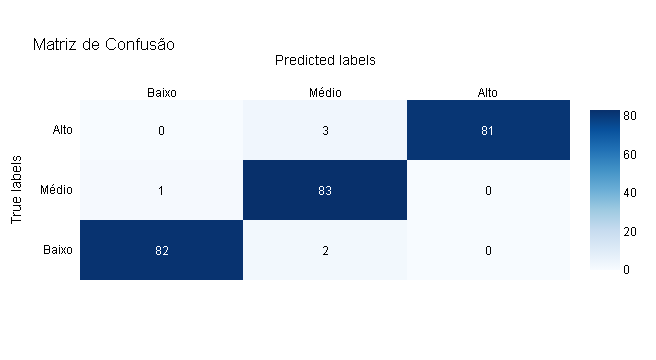

In [28]:
conf_matrix = confusion_matrix(y_train, y_pred_train)

# Definindo  nomes de classes
class_names = ['Baixo', 'Médio', 'Alto' ]

# Plotando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Predicted labels',
    yaxis_title='True labels',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

In [31]:
conf_matrix = confusion_matrix(y_train, y_pred_train)

conf_matrix

array([[82,  2,  0],
       [ 1, 83,  0],
       [ 0,  3, 81]])

In [32]:
246/252

0.9761904761904762

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

O modelo teve acurácia alta (0,976) e bom recall (0,944) nos dados de teste, mostrando que funciona bem com dados novos. A matriz de confusão indica apenas um erro, com a maioria das previsões corretas em todas as classes.
Além disso, os resultados de treino e teste são bem parecidos, o que mostra que o modelo generaliza bem e não apresenta problemas de overfitting.

In [33]:
#seu código aqui
y_pred_test = naive_churn.predict(X_test)

In [35]:
accuracy = accuracy_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test, average='macro')


print("Acurácia:", accuracy)
print("Recall:", recall)

Acurácia: 0.975609756097561
Recall: 0.9444444444444445


In [36]:
conf_matrix = confusion_matrix(y_test, y_pred_test)

conf_matrix

array([[ 5,  1,  0],
       [ 0,  6,  0],
       [ 0,  0, 29]])

In [37]:
print("Valores Previstos:")
print(y_pred_test)

Valores Previstos:
[1 2 1 2 2 1 2 2 2 2 1 0 2 2 0 2 2 0 2 2 2 0 1 2 2 2 2 2 2 1 2 2 2 2 2 2 2
 1 2 0 2]


print("\nValores Reais:")
print(y_test)

# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.
Utilize pelo menos 4 linhas.

Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!

Neste projeto, usamos uma base de dados de crédito para analisar informações dos clientes e prever se o score deles é baixo, médio ou alto. Para isso, aplicamos o algoritmo Naive Bayes, que faz classificações com base em probabilidades.
O objetivo principal foi criar um modelo que consiga prever corretamente a categoria de crédito dos clientes e verificar se ele também funciona bem com dados novos, ajudando na análise de risco e na tomada de decisão.